### ***Опис колонок ДатаСету:***

 ***date:*** дата замовлення;

 ***session_id:*** ідентифікатор сесії;

 ***continent:*** континент;

 ***country:*** країна;

 ***device:*** девайс;

 ***browser:*** браузер;

 ***mobile_model_name:*** назва моделі пристрою;

 ***operating_system:*** операційна система;

 ***language:*** мова браузера;

 ***traffic_source:*** інформація про джерело трафіку;

 ***channel:*** канал трафіку;

 ***account_id:*** ідентифікатор зареєстрованого користувача;

 ***is_verified:*** чи підтвердив користувач свій email;

 ***is_unsubscribed:*** чи відписався користувач від розсилки;

 ***category:*** категорія товару;

 ***product_name:*** назва товару;

 ***price:*** ціна;

 ***description:*** короткий опис товару.

In [1]:
from google.colab import auth, files
auth.authenticate_user()
from google.cloud import bigquery

import pandas as pd
import numpy as np

from scipy.stats import pearsonr, spearmanr, mannwhitneyu
import statsmodels.api as sm
from statsmodels.stats.proportion import proportions_ztest

import seaborn as sns
import matplotlib.pyplot as plt

print('Authenticated')

Authenticated


In [2]:
!pip install google-cloud

# 📌***1. Створення ДатаСету***

✅ ***Підключення до DB bigquery***

In [3]:
PROJECT_ID = "data-analytics-mate"

client = bigquery.Client(project=PROJECT_ID)

✅ ***Запит до DB для формування датасету на основі таблиць***

In [4]:
query = """
    SELECT
    s.date as date,
    s.ga_session_id as session_id,
    sp.continent,
    sp.country,
    sp.device,
    sp.browser,
    sp.mobile_model_name,
    sp.operating_system,
    sp.language,
    sp.medium as traffic_source,
    sp.channel,
    acs.account_id,
    ac.is_verified,
    ac.is_unsubscribed,
    p.category,
    p.name as product_name,
    p.price,
    p.short_description as description
    FROM `DA.session` as s
    LEFT JOIN `DA.session_params` as sp
    ON s.ga_session_id = sp.ga_session_id
    LEFT JOIN `DA.account_session` as acs
    ON s.ga_session_id = acs.ga_session_id
    LEFT JOIN `DA.account` as ac
    ON acs.account_id = ac.id
    LEFT JOIN `DA.order` as o
    ON s.ga_session_id = o.ga_session_id
    LEFT JOIN `DA.product` as p
    ON o.item_id = p.item_id
"""

df = client.query(query).result().to_dataframe(create_bqstorage_client=False)
df.head()

,date,session_id,continent,country,device,browser,mobile_model_name,operating_system,language,traffic_source,channel,account_id,is_verified,is_unsubscribed,category,product_name,price,description
0,2020-11-01,5760483956,Americas,United States,desktop,Chrome,Safari,Macintosh,zh,<Other>,Paid Search,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
1,2020-11-01,7115337200,Europe,United Kingdom,desktop,Chrome,Chrome,Web,en-us,organic,Organic Search,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
2,2020-11-01,3978035233,Europe,Norway,mobile,Chrome,<Other>,Web,zh,(none),Direct,<NA>,<NA>,<NA>,Tables & desks,RÅSKOG,189.0,"Trolley, 35x45x78 cm"
3,2020-11-01,9648986282,Africa,Nigeria,mobile,Chrome,<Other>,Android,es-es,(none),Direct,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
4,2020-11-01,4393441533,Asia,China,desktop,Chrome,Chrome,Windows,en-us,(none),Direct,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"


#📌***2. Розуміння даних та їх змісту***

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   date               349545 non-null  dbdate 
 1   session_id         349545 non-null  Int64  
 2   continent          349545 non-null  object 
 3   country            349545 non-null  object 
 4   device             349545 non-null  object 
 5   browser            349545 non-null  object 
 6   mobile_model_name  349545 non-null  object 
 7   operating_system   349545 non-null  object 
 8   language           235279 non-null  object 
 9   traffic_source     349545 non-null  object 
 10  channel            349545 non-null  object 
 11  account_id         27945 non-null   Int64  
 12  is_verified        27945 non-null   Int64  
 13  is_unsubscribed    27945 non-null   Int64  
 14  category           33538 non-null   object 
 15  product_name       33538 non-null   object 
 16  pr

In [6]:
df.describe()

,session_id,account_id,is_verified,is_unsubscribed,price
count,349545.0,27945.0,27945.0,27945.0,33538.000000
mean,4992250296.631739,659005.065557,0.71698,0.16944,953.298679
std,2887450949.537772,13216.529465,0.450474,0.375147,1317.001775
min,1205.0,636133.0,0.0,0.0,3.000000
25%,2493646855.0,647576.0,0.0,0.0,170.000000
50%,4988476074.0,658952.0,1.0,0.0,445.000000
75%,7491286508.0,670414.0,1.0,0.0,1195.000000
max,9999997129.0,681962.0,1.0,1.0,9585.000000


In [7]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   date               349545 non-null  datetime64[ns]
 1   session_id         349545 non-null  Int64         
 2   continent          349545 non-null  object        
 3   country            349545 non-null  object        
 4   device             349545 non-null  object        
 5   browser            349545 non-null  object        
 6   mobile_model_name  349545 non-null  object        
 7   operating_system   349545 non-null  object        
 8   language           235279 non-null  object        
 9   traffic_source     349545 non-null  object        
 10  channel            349545 non-null  object        
 11  account_id         27945 non-null   Int64         
 12  is_verified        27945 non-null   Int64         
 13  is_unsubscribed    27945 non-null   Int64   

✅ ***Розмір датасету***

In [8]:
df.shape

(349545, 18)

✅ ***Загальна кількість колонок***

In [9]:
print('загальна кількість колонок:', df.shape[1])

загальна кількість колонок: 18


✅ ***Кількість та назва колонок числового типу***

In [10]:
numeric_df = df.select_dtypes(include=['number'])
print('кількість колонок числового типу:',  numeric_df.shape[1])
print('які саме колонки числового типу:',  numeric_df.columns.to_list())

кількість колонок числового типу: 5
які саме колонки числового типу: ['session_id', 'account_id', 'is_verified', 'is_unsubscribed', 'price']


✅ ***Кількість та назва колонок категоріального типу***

In [11]:
categ_df = df.select_dtypes(include=['object', 'category'])
print('кількість колонок категоріального типу:',  categ_df.shape[1])
print('які саме колонки категоріального типу:',  categ_df.columns.tolist())

кількість колонок категоріального типу: 12
які саме колонки категоріального типу: ['continent', 'country', 'device', 'browser', 'mobile_model_name', 'operating_system', 'language', 'traffic_source', 'channel', 'category', 'product_name', 'description']


✅ ***Кількість колонок типу datetime***

In [12]:
datetime_df = df.select_dtypes(include=['dbdate', 'datetime'])
print('кількість колонок числового типу:',  datetime_df.shape[1])
print('які саме колонки числового типу:',  datetime_df.columns.to_list())

кількість колонок числового типу: 1
які саме колонки числового типу: ['date']


✅ ***Кількість унікальних сесій***

In [13]:
print('кількість унікальних сесій:', len(pd.unique(df['session_id'])))

кількість унікальних сесій: 349545


✅ ***Період часу***

In [14]:
print(f'період часу розглядається з {min(df['date'])} до {max(df['date'])}')

період часу розглядається з 2020-11-01 00:00:00 до 2021-01-31 00:00:00


✅ ***Наявність пропущених значень та їх доля***

In [15]:
missing_values = df.isna().sum()
print("Пропущені значення:", missing_values)

missing_percent  = df.isna().mean() * 100
print("\nДоля пропущених значення:", round(missing_percent , 1))

Пропущені значення: date                      0
session_id                0
continent                 0
country                   0
device                    0
browser                   0
mobile_model_name         0
operating_system          0
language             114266
traffic_source            0
channel                   0
account_id           321600
is_verified          321600
is_unsubscribed      321600
category             316007
product_name         316007
price                316007
description          316007
dtype: int64

Доля пропущених значення: date                  0.0
session_id            0.0
continent             0.0
country               0.0
device                0.0
browser               0.0
mobile_model_name     0.0
operating_system      0.0
language             32.7
traffic_source        0.0
channel               0.0
account_id           92.0
is_verified          92.0
is_unsubscribed      92.0
category             90.4
product_name         90.4
price               

In [16]:
print(missing_values[missing_values > 0].sort_values())

language           114266
price              316007
product_name       316007
category           316007
description        316007
is_unsubscribed    321600
account_id         321600
is_verified        321600
dtype: int64


✅ ***Наявність дублікатів***

In [17]:
print("Дублікати:", df.duplicated().sum())

Дублікати: 0


✅ ***Заповнення пропущених значень в колонках:***

 `language` – заповнення значенням ***`Unknown`***;

  `account_id`, `is_verified`, `is_unsubscribed` – гостьові сесії;

  `category`, `product_name`, `description` – сесії без покупки ***`No Purchase`***



---


Заповнення значенням:
  `Unknown`, `No Purchase`. Маніпуляції з даними збереже записи у вибірці, для уникнення викривлення статистики








In [18]:
df['language'] = df['language'].fillna('Unknown')
df['language'].unique()

array(['zh', 'en-us', 'es-es', 'Unknown', 'en-gb', 'en-ca', 'fr', 'ko',
       'en', 'de'], dtype=object)

In [19]:
df['account_id'] = df['account_id'].fillna(0).astype('int64')
df['is_verified'] = df['is_verified'].fillna(0).astype(bool)
df['is_unsubscribed'] = df['is_unsubscribed'].fillna(0).astype(bool)

print(df[['account_id', 'is_verified', 'is_unsubscribed']].isnull().sum())

account_id         0
is_verified        0
is_unsubscribed    0
dtype: int64


In [20]:
df['category'] = df['category'].fillna('No Purchase')
df['product_name'] = df['product_name'].fillna('No Purchase')
df['description'] = df['description'].fillna('No Purchase')

print(df[['category', 'product_name', 'description']].isnull().sum())

category        0
product_name    0
description     0
dtype: int64


In [21]:
df.head()

,date,session_id,continent,country,device,browser,mobile_model_name,operating_system,language,traffic_source,channel,account_id,is_verified,is_unsubscribed,category,product_name,price,description
0,2020-11-01,5760483956,Americas,United States,desktop,Chrome,Safari,Macintosh,zh,<Other>,Paid Search,0,False,False,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
1,2020-11-01,7115337200,Europe,United Kingdom,desktop,Chrome,Chrome,Web,en-us,organic,Organic Search,0,False,False,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
2,2020-11-01,3978035233,Europe,Norway,mobile,Chrome,<Other>,Web,zh,(none),Direct,0,False,False,Tables & desks,RÅSKOG,189.0,"Trolley, 35x45x78 cm"
3,2020-11-01,9648986282,Africa,Nigeria,mobile,Chrome,<Other>,Android,es-es,(none),Direct,0,False,False,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
4,2020-11-01,4393441533,Asia,China,desktop,Chrome,Chrome,Windows,en-us,(none),Direct,0,False,False,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"


In [22]:
print(df.groupby('session_id').size().value_counts())

print(df.groupby('session_id').size()[df.groupby('session_id').size() > 1].count())

1    349545
Name: count, dtype: int64
0


In [23]:
# df.to_csv('updated_df.csv', index=False)

# files.download('updated_df.csv')

✅ ***топ-3 континенти та топ-5 країн, в яких компанія має найбільші продажі та найбільшу кількість замовлень***

🔷 ***копія ДатаСету з покупками, на основі нього подальший аналіз ДатаСету***

In [24]:
df_purchases = df[df['price'].notna()].copy()
df_purchases.shape

(33538, 18)

In [25]:
# df_purchases.to_csv('df_purchases.csv', index=False)

In [26]:
# files.download('df_purchases.csv')

In [27]:
top_continents = df_purchases.groupby('continent').agg(total_profit=('price', 'sum'),count_order=('session_id', 'count')).nlargest(3, 'total_profit')
print("Tоп-3 континенти в яких компанія має найбільші продажі та кількість замовлень")
print(top_continents)

Tоп-3 континенти в яких компанія має найбільші продажі та кількість замовлень
           total_profit  count_order
continent                           
Americas     17665280.0        18553
Asia          7601298.3         7950
Europe        5934624.2         6261


In [28]:
top_countries = df_purchases.groupby('country').agg(total_profit=('price', 'sum'),count_order=('session_id', 'count')).nlargest(5, 'total_profit').reset_index()
print("Tоп-5 країн в яких компанія має найбільші продажі та кількість замовлень")
print(top_countries)

Tоп-5 країн в яких компанія має найбільші продажі та кількість замовлень
          country  total_profit  count_order
0   United States    13943553.9        14673
1           India     2809762.0         3029
2          Canada     2437921.0         2560
3  United Kingdom      938317.9         1029
4          France      710692.8          678


✅***топ-10 категорій товарів за загальною сумою продажів***

In [29]:
top_categories = df_purchases.groupby('category').agg(total_profit=('price', 'sum')).nlargest(10, 'total_profit').reset_index()
print("Tоп-10 категорій товарів за загальною сумою продажів")
print(top_categories)

Tоп-10 категорій товарів за загальною сумою продажів
                           category  total_profit
0                 Sofas & armchairs     8388254.5
1                            Chairs     6147748.8
2                              Beds     4919725.0
3        Bookcases & shelving units     3640818.1
4              Cabinets & cupboards     2336499.5
5                 Outdoor furniture     2142222.2
6                    Tables & desks     1790307.5
7  Chests of drawers & drawer units      906562.5
8                     Bar furniture      735503.0
9              Children's furniture      467697.0


✅ ***топ-10 категорій товарів у країні з найбільшими продажами, чи відрізняється ситуація від загальної?***

 🔷 ***країна з найбільшими продажами***

In [30]:
top_country = df_purchases.groupby('country').agg(total_profit=('price', 'sum')).nlargest(1, 'total_profit').index[0]
print("Tоп країна з найбільшими продажами –", top_country )

Tоп країна з найбільшими продажами – United States


🔷 ***топ-10 категорій по цій країні***

In [31]:
top_categories_country = (df_purchases[df_purchases['country'] == top_country]
                          .groupby('category').agg(total_profit_USA=('price', 'sum'),count_order_USA=('session_id', 'count'))
                          .nlargest(10, 'total_profit_USA'))
print('топ-10 категорій товарів по цій країні')
print(top_categories_country)

топ-10 категорій товарів по цій країні
                                  total_profit_USA  count_order_USA
category                                                           
Sofas & armchairs                        3707144.5             1903
Chairs                                   2619773.8             2576
Beds                                     2213058.0             1298
Bookcases & shelving units               1567606.9             3374
Cabinets & cupboards                      994545.5              995
Outdoor furniture                         929245.2              984
Tables & desks                            777865.0             1248
Chests of drawers & drawer units          382388.0              616
Bar furniture                             330805.0              487
Children's furniture                      207575.0              752


🔷 ***загальна картина для порівняння. Дані по профіту та кількості замовлень вцілому***

In [32]:
top_categories_global = df_purchases.groupby('category').agg(total_profit_global=('price', 'sum'),count_order_global=('session_id', 'count')).nlargest(10, 'total_profit_global')
print(top_categories_global)

                                  total_profit_global  count_order_global
category                                                                 
Sofas & armchairs                           8388254.5                4301
Chairs                                      6147748.8                5952
Beds                                        4919725.0                2926
Bookcases & shelving units                  3640818.1                7630
Cabinets & cupboards                        2336499.5                2318
Outdoor furniture                           2142222.2                2229
Tables & desks                              1790307.5                2941
Chests of drawers & drawer units             906562.5                1452
Bar furniture                                735503.0                1092
Children's furniture                         467697.0                1702


🔷 ***мердж даних по США та Глобал в один датафрейм***

In [33]:
diff_profit_count = pd.merge(top_categories_country, top_categories_global, on="category", how="inner").reset_index()
print(diff_profit_count)

                           category  total_profit_USA  count_order_USA  \
0                 Sofas & armchairs         3707144.5             1903   
1                            Chairs         2619773.8             2576   
2                              Beds         2213058.0             1298   
3        Bookcases & shelving units         1567606.9             3374   
4              Cabinets & cupboards          994545.5              995   
5                 Outdoor furniture          929245.2              984   
6                    Tables & desks          777865.0             1248   
7  Chests of drawers & drawer units          382388.0              616   
8                     Bar furniture          330805.0              487   
9              Children's furniture          207575.0              752   

   total_profit_global  count_order_global  
0            8388254.5                4301  
1            6147748.8                5952  
2            4919725.0                2926  
3    

🔷 ***загальна картина об'єднаних даних***

In [34]:
diff_profit_count['share_profit'] = (diff_profit_count['total_profit_USA'] / diff_profit_count['total_profit_global']) *100
diff_profit_count['share_count_orders'] = (diff_profit_count['count_order_USA'] / diff_profit_count['count_order_global']) *100

diff_profit_count

,category,total_profit_USA,count_order_USA,total_profit_global,count_order_global,share_profit,share_count_orders
0,Sofas & armchairs,3707144.5,1903,8388254.5,4301,44.194469,44.245524
1,Chairs,2619773.8,2576,6147748.8,5952,42.613547,43.27957
2,Beds,2213058.0,1298,4919725.0,2926,44.983368,44.360902
3,Bookcases & shelving units,1567606.9,3374,3640818.1,7630,43.056447,44.220183
4,Cabinets & cupboards,994545.5,995,2336499.5,2318,42.565620,42.924935
5,Outdoor furniture,929245.2,984,2142222.2,2229,43.377629,44.145357
6,Tables & desks,777865.0,1248,1790307.5,2941,43.448681,42.434546
7,Chests of drawers & drawer units,382388.0,616,906562.5,1452,42.179993,42.424242
8,Bar furniture,330805.0,487,735503.0,1092,44.976703,44.59707
9,Children's furniture,207575.0,752,467697.0,1702,44.382367,44.183314


In [35]:
print(diff_profit_count.columns)

Index(['category', 'total_profit_USA', 'count_order_USA',
       'total_profit_global', 'count_order_global', 'share_profit',
       'share_count_orders'],
      dtype='object')


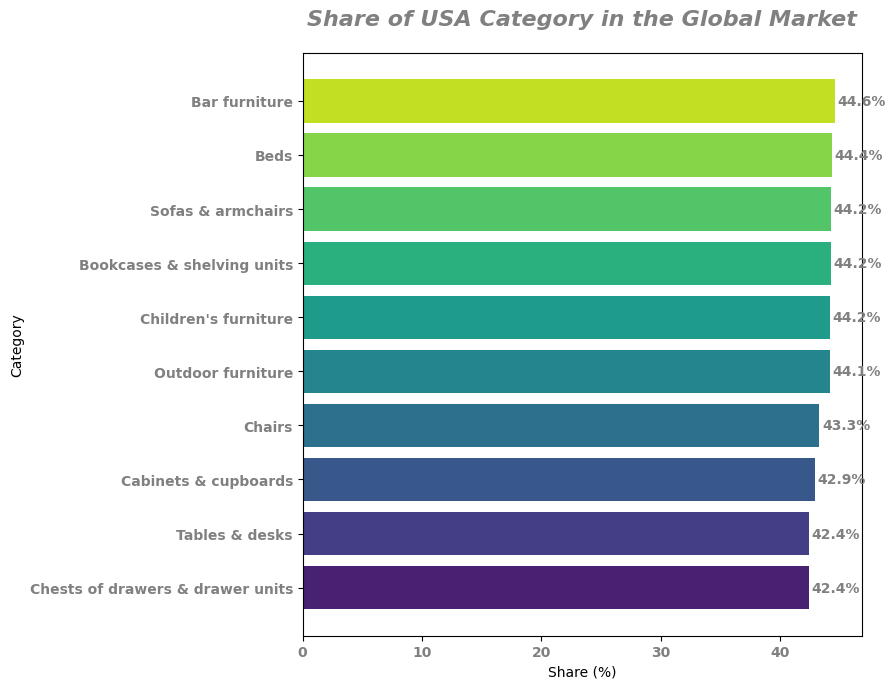

In [36]:
df_plot = diff_profit_count.sort_values('share_count_orders')

fig, ax = plt.subplots(figsize=(9, 7))

bars = ax.barh(df_plot['category'], df_plot['share_count_orders'], color=sns.color_palette("viridis", len(df_plot)))

for i, v in enumerate(df_plot['share_count_orders']):
    ax.text(v + 0.2, i, f"{v:.1f}%", va='center',
            fontsize=10, fontweight='bold', color='grey')

ax.set_title('Share of USA Category in the Global Market', fontsize=16, fontweight='semibold', color='grey', fontstyle="italic", pad=20)

ax.set_xlabel("Share (%)")
ax.set_ylabel("Category")

plt.xticks(color="grey", fontweight='bold')
plt.yticks(color="grey", fontweight='bold')

plt.tight_layout()
plt.show()

####❤️ ***Висновок:***


Частка між USA та глобальними показниками є стабільною:

*  profit `share_profit` коливається в межах ~42%-45%,

*  кількість замовлень `share_count_orders` – ~42-44%.

Ринок USA займає ключову роль, приблизно 44%, як прибутк, так і замовлень у ТОП-10 категорій товарів.

Спостерігається:
* рівномірна структура попиту між категоріями;
* синхронність профіту та замовлень, що свідчить про відсутність суттєвих відмінностей у середньому чеку між USA та глобальним ринком.





##✅ ***Динаміка продажів + сезонність***

🔷***Аналіз продажів за днями тижня:***

In [37]:
df_purchases_by_weekday = df_purchases.assign(order_weekday=df_purchases["date"].dt.day_name())
df_purchases_by_weekday.head()

,date,session_id,continent,country,device,browser,mobile_model_name,operating_system,language,traffic_source,channel,account_id,is_verified,is_unsubscribed,category,product_name,price,description,order_weekday
0,2020-11-01,5760483956,Americas,United States,desktop,Chrome,Safari,Macintosh,zh,<Other>,Paid Search,0,False,False,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm",Sunday
1,2020-11-01,7115337200,Europe,United Kingdom,desktop,Chrome,Chrome,Web,en-us,organic,Organic Search,0,False,False,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm",Sunday
2,2020-11-01,3978035233,Europe,Norway,mobile,Chrome,<Other>,Web,zh,(none),Direct,0,False,False,Tables & desks,RÅSKOG,189.0,"Trolley, 35x45x78 cm",Sunday
3,2020-11-01,9648986282,Africa,Nigeria,mobile,Chrome,<Other>,Android,es-es,(none),Direct,0,False,False,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm",Sunday
4,2020-11-01,4393441533,Asia,China,desktop,Chrome,Chrome,Windows,en-us,(none),Direct,0,False,False,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm",Sunday


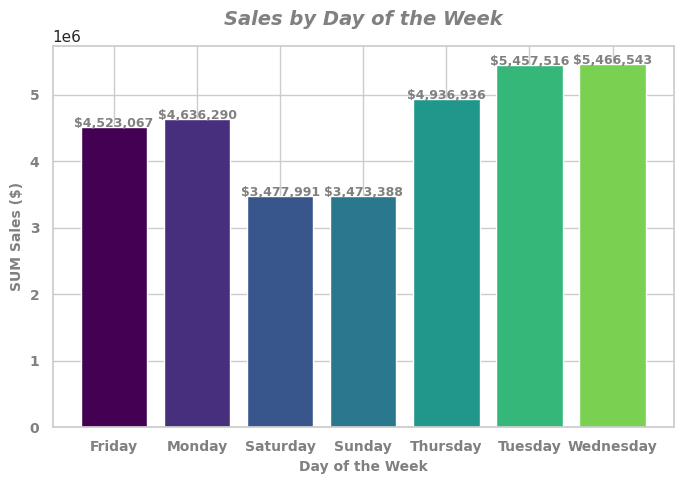

In [38]:
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(7, 5))

weekday_sales = df_purchases_by_weekday.groupby('order_weekday')['price'].sum().reset_index()

bars = ax.bar(weekday_sales['order_weekday'], weekday_sales['price'],
              color=plt.cm.viridis(np.linspace(0, 0.8, len(weekday_sales))))

ax.set_title('Sales by Day of the Week',
             fontsize=14, fontweight='semibold',
             color='grey', fontstyle='italic', pad=15)

ax.set_xlabel('Day of the Week', color='grey', fontweight='bold', fontsize=10)
ax.set_ylabel('SUM Sales ($)', color='grey', fontweight='bold', fontsize=10)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'${bar.get_height():,.0f}',
            ha='center', color='grey', fontweight='bold', fontsize=9)

plt.xticks(color='grey', fontweight='bold', fontsize=10)
plt.yticks(color='grey', fontweight='bold', fontsize=10)
plt.tight_layout()
plt.show()

###❤️ ***Висновок: Динаміки продажів + сезонність***

***Пік продажів спостерігаєтся вівторк-середа, з четверга поступово змешується, з понеділка – зростає.***

🔷***Аналіз продажів за сезонністю:***

In [39]:
seasons_map = {12: 'Winter', 1: 'Winter', 2: 'Winter',
           3: 'Spring', 4: 'Spring', 5: 'Spring',
           6: 'Summer', 7: 'Summer', 8: 'Summer',
           9: 'Autumn', 10: 'Autumn', 11: 'Autumn'}

df_purchases_by_seasons = df_purchases_by_weekday.assign(season=df_purchases_by_weekday["date"].dt.month.map(seasons_map))
df_purchases_by_seasons.head()

,date,session_id,continent,country,device,browser,mobile_model_name,operating_system,language,traffic_source,channel,account_id,is_verified,is_unsubscribed,category,product_name,price,description,order_weekday,season
0,2020-11-01,5760483956,Americas,United States,desktop,Chrome,Safari,Macintosh,zh,<Other>,Paid Search,0,False,False,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm",Sunday,Autumn
1,2020-11-01,7115337200,Europe,United Kingdom,desktop,Chrome,Chrome,Web,en-us,organic,Organic Search,0,False,False,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm",Sunday,Autumn
2,2020-11-01,3978035233,Europe,Norway,mobile,Chrome,<Other>,Web,zh,(none),Direct,0,False,False,Tables & desks,RÅSKOG,189.0,"Trolley, 35x45x78 cm",Sunday,Autumn
3,2020-11-01,9648986282,Africa,Nigeria,mobile,Chrome,<Other>,Android,es-es,(none),Direct,0,False,False,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm",Sunday,Autumn
4,2020-11-01,4393441533,Asia,China,desktop,Chrome,Chrome,Windows,en-us,(none),Direct,0,False,False,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm",Sunday,Autumn


In [40]:
df_purchases_by_seasons['season'].unique()

array(['Autumn', 'Winter'], dtype=object)

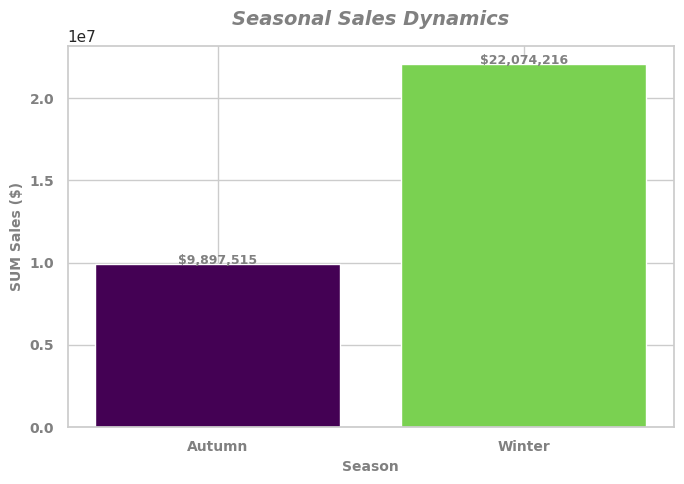

In [41]:
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(7, 5))

season_sales = df_purchases_by_seasons.groupby('season')['price'].sum().reset_index()

bars = ax.bar(season_sales['season'], season_sales['price'],
              color=plt.cm.viridis(np.linspace(0, 0.8, len(season_sales))))

ax.set_title('Seasonal Sales Dynamics',
             fontsize=14, fontweight='semibold',
             color='grey', fontstyle='italic', pad=15)

ax.set_xlabel('Season', color='grey', fontweight='bold', fontsize=10)
ax.set_ylabel('SUM Sales ($)', color='grey', fontweight='bold', fontsize=10)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'${bar.get_height():,.0f}',
            ha='center', color='grey', fontweight='bold', fontsize=9)

plt.xticks(color='grey', fontweight='bold', fontsize=10)
plt.yticks(color='grey', fontweight='bold', fontsize=10)
plt.tight_layout()
plt.show()

###❤️ ***Висновок:***

***Пік продажів спостерігаєтся взимку, восени продажі падають вдвічі. Весна-літо прлдажі відсутні.***

In [42]:
df_purchases['traffic_source'].unique()

array(['<Other>', 'organic', '(none)', '(data deleted)', 'referral',
       'cpc'], dtype=object)

###✅ ***Канали трафіку VS девайси***

In [43]:
device_channel = pd.pivot_table(df_purchases, values="price", index=["device", "channel"], aggfunc="sum")
device_channel.sort_values(by='price', ascending=False).reset_index()

,device,channel,price
0,desktop,Organic Search,6794107.8
1,desktop,Paid Search,4976977.8
2,desktop,Direct,4472609.4
3,mobile,Organic Search,4408875.1
4,mobile,Paid Search,3330032.6
5,mobile,Direct,2875317.9
6,desktop,Social Search,1447384.8
7,desktop,Undefined,1172959.2
8,mobile,Social Search,1006707.3
9,mobile,Undefined,763292.9


(array([       0.,  2500000.,  5000000.,  7500000., 10000000., 12500000.,
        15000000., 17500000., 20000000.]),
 [Text(0, 0.0, '0.00'),
  Text(0, 2500000.0, '0.25'),
  Text(0, 5000000.0, '0.50'),
  Text(0, 7500000.0, '0.75'),
  Text(0, 10000000.0, '1.00'),
  Text(0, 12500000.0, '1.25'),
  Text(0, 15000000.0, '1.50'),
  Text(0, 17500000.0, '1.75'),
  Text(0, 20000000.0, '2.00')])

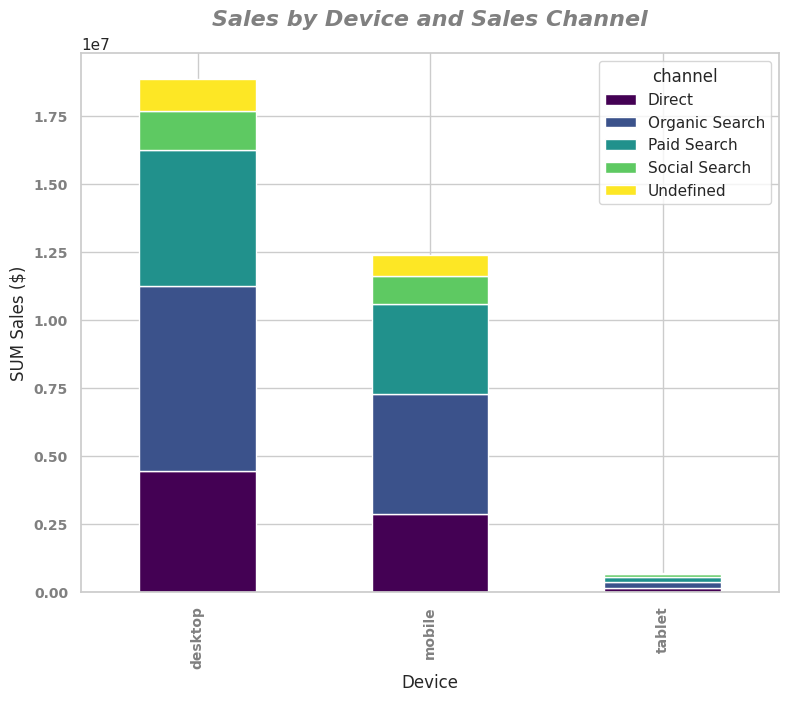

In [44]:
pivot = device_channel.reset_index().pivot(index='device', columns='channel', values='price')
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(9, 7))

pivot.plot(kind='bar', stacked=True, ax=ax, colormap='viridis')

ax.set_title('Sales by Device and Sales Channel', fontsize=16, fontweight='semibold', color='grey', fontstyle='italic', pad=20)

ax.set_xlabel('Device')
ax.set_ylabel('SUM Sales ($)')

plt.xticks(color="grey", fontweight='bold', fontsize=10)
plt.yticks(color="grey", fontweight='bold', fontsize=10)

###❤️ ***Висновок:*** ***Канали трафіку VS девайси***
***Девайси:***

* Desktop – головний драйвер п замовленню;
* Mobile - стабільно відстаєж;
* Tablet - майже немає замовлень.

***Основні гроші приходять з Desktop, Mobile - важливий, але не ключовий***

---


***Канал трафіку вцілому:***

* Organic Search – топ канал;
* Paid Search — другий;
* Direct — третій;
* Social, Undefined — значно слабші.


***Канал трафіку по Device:***

* Desktop – сильний по всім каналах, особливо, Organic та Paid Search;
* Mobile - повторює структуру Desktop, але по сумам відстає;
* Tablet - низькі показники.



---

***Desktop -> Mobile -> Tablet***

***Organic -> Paid -> Direct -> Social -> Undefind***

Desktop генерують високі продажі (дохід) з усіх каналів, причому Organic Search є головним фактором. Mobile демонструють схожі моделі трафіку, але нижчу монетизацію, що вказує на можливості оптимізації.



#***📌 3. Статистичний аналіз***

##***✅ Кореляція сесій та продажів (pearson/spearman + p-value)***

In [45]:
data_session_price = df.groupby('date').agg(count_order=('session_id', 'nunique'), total_profit=('price', 'sum')).reset_index()
data_session_price.head()

,date,count_order,total_profit
0,2020-11-01,2576,244292.5
1,2020-11-02,3599,355506.8
2,2020-11-03,5173,498979.6
3,2020-11-04,4184,339187.1
4,2020-11-05,3743,391276.6


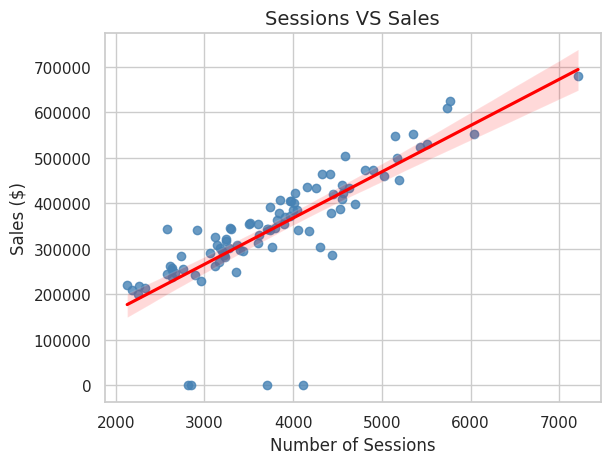

In [46]:
sns.regplot(
    data=data_session_price,
    x="count_order",
    y="total_profit",
    scatter_kws={"color": "steelblue"},
    line_kws={"color": "red"}
)

plt.title('Sessions VS Sales', fontsize=14)
plt.xlabel('Number of Sessions')
plt.ylabel('Sales ($)')

plt.show()

In [47]:
print(f"\nТест статистики кореляція сесій та продажів (pearson + p-value):{pearsonr(data_session_price['count_order'], data_session_price['total_profit'])}")

pearson_corr_data_session_price = data_session_price["count_order"].corr(data_session_price["total_profit"])
print(f"\nКореляція pearsonr: {pearson_corr_data_session_price}")

print(f"\nTест сатистики кореляція сесій та продажів (spearmanr + p-value): {spearmanr(data_session_price['count_order'], data_session_price['total_profit'])}")

spearman_corr_data_session_price = data_session_price["count_order"].corr(data_session_price["total_profit"], method="spearman")
print(f"\nКореляція spearmanr: {spearman_corr_data_session_price}")


Тест статистики кореляція сесій та продажів (pearson + p-value):PearsonRResult(statistic=np.float64(0.7910809164540891), pvalue=np.float64(6.483532312080735e-21))

Кореляція pearsonr: 0.7910809164540887

Tест сатистики кореляція сесій та продажів (spearmanr + p-value): SignificanceResult(statistic=np.float64(0.8653062174563682), pvalue=np.float64(9.755923586156614e-29))

Кореляція spearmanr: 0.8653062174563682


###***❤️Висновок:*** **кореляції між кількістю сесій та продажами**

* pearson – 0.791 – сильна лінійна кореляція;
* spearmanr – 0.865 – сильна кореляція;
* p-value < 0.05 -> кореляція статистично значуща

***Обидва тести підтверджують, що більше трафіку на сайт прямо пов'язано з більшими продажами.***




##✅***Mann-Whitney U тест:***

* ***Зареєстровані vs Гостьові***

* ***Відписані vs Підписані на розсилку***

* ***Верифіковані vs Не верифіковані email***



🔷***Зареєстровані vs Гостьові***

In [48]:
registered = df_purchases[df_purchases['account_id'] != 0]['price']
guest = df_purchases[df_purchases['account_id'] == 0]['price']

print(f'Зареєстровані покупки: {len(registered)}, cередня ціна: {registered.mean():.2f}')
print(f'Гостьові покупки: {len(guest)}, cередня ціна: {guest.mean():.2f}')

Зареєстровані покупки: 2781, cередня ціна: 928.63
Гостьові покупки: 30757, cередня ціна: 955.53



🔷 ***Верифіковані vs Не верифіковані email***

🔷 ***Відписані vs Підписані на розсилку***

In [49]:
verified = df_purchases[df_purchases['is_verified'] == True]['price']
not_verified = df_purchases[df_purchases['is_verified'] == False]['price']

unsubscribed = df_purchases[df_purchases['is_unsubscribed'] == True]['price']
still_subscribed = df_purchases[df_purchases['is_unsubscribed'] == False]['price']

print(f'Верифіковані: {len(verified)}, cередня ціна: {verified.mean():.2f}')
print(f'Не верифіковані: {len(not_verified)}, cередня ціна: {not_verified.mean():.2f}')
print(f'Відписані: {len(unsubscribed)}, cередня ціна: {unsubscribed.mean():.2f}')
print(f'Підписані: {len(still_subscribed)}, cередня ціна: {still_subscribed.mean():.2f}')

Верифіковані: 1989, cередня ціна: 938.17
Не верифіковані: 31549, cередня ціна: 954.25
Відписані: 447, cередня ціна: 965.82
Підписані: 33091, cередня ціна: 953.13


In [50]:
u_stat1, p_value1 = mannwhitneyu(registered, guest, alternative='two-sided')
print(f"U-statistic зареєстровані чи гостьові покупки: {u_stat1}, p-value: {p_value1}")

u_stat2, p_value2 = mannwhitneyu(verified, not_verified, alternative='two-sided')
print(f"U-statistic верифікований чи не верифікований: {u_stat2}, p-value: {p_value2}")

u_stat3, p_value3 = mannwhitneyu(unsubscribed, still_subscribed, alternative='two-sided')
print(f"U-statistic відписані чи підписаний: {u_stat3}, p-value: {p_value3}")

U-statistic зареєстровані чи гостьові покупки: 41771375.0, p-value: 0.041590896614016215
U-statistic верифікований чи не верифікований: 30920347.0, p-value: 0.27711748323156726
U-statistic відписані чи підписаний: 7496414.5, p-value: 0.6208359779641769


 🔷***Результат Mann-Whitney U тестів:***

In [51]:
print(f"""
Результат Mann-Whitney U тестів:

1. Зареєстровані vs Гостьові
   U-statistic: {u_stat1:.2f}, p-value: {p_value1:.4f}
   {'Різниця значуща ✅' if p_value1 < 0.05 else 'Різниці немає ❌'}

2. Верифіковані vs Не верифіковані email
   U-statistic: {u_stat2:.2f}, p-value: {p_value2:.4f}
   {'Різниця значуща ✅' if p_value2 < 0.05 else 'Різниці немає ❌'}

3. Відписані vs Підписані на розсилку
   U-statistic: {u_stat3:.2f}, p-value: {p_value3:.4f}
   {'Різниця значуща ✅' if p_value3 < 0.05 else 'Різниці немає ❌'}
""")


Результат Mann-Whitney U тестів:

1. Зареєстровані vs Гостьові
   U-statistic: 41771375.00, p-value: 0.0416
   Різниця значуща ✅

2. Верифіковані vs Не верифіковані email
   U-statistic: 30920347.00, p-value: 0.2771
   Різниці немає ❌

3. Відписані vs Підписані на розсилку
   U-statistic: 7496414.50, p-value: 0.6208
   Різниці немає ❌



###***❤️Висновки: Mann-Whitney U тести***

* ***Зареєстровані vs Гостьові*** *(p-value = 0.0416 < 0.05)*

*Різниця статистично значуща. Зареєстровані користувачі витрачають статистично більше ніж гостьові покупці. Реєстрація на сайті пов'язана з іншою поведінкою.*


---


* ***Відписані vs Підписані на розсилку*** *(p-value = 0.6208 > 0.05)*

*Різниця статистично НЕ значуща. Підписка на розсилку не впливає на суму покупок. E-mail не є визначальним фактором для роміру замовлення.*



---


* ***Верифіковані vs Не верифіковані email*** *(p-value = 0.2771 > 0.05)*

*Різниця статистично НЕ значуща. Підтвердження E-mail не впливає на суму покупок. Верифікація не змінює повеінку користувача.*


---

*Програма Pеєстрації має сенс - зареєстровані користувачі поводяться інакше при покупках. Варто інвестувати в заохочення реєстрації.*

###***✅  Органічний трафік Європа vs Америка - Z-тест для часток***

In [52]:
europe = df[df['continent'] == 'Europe']
america = df[df['continent'] == 'Americas']

europe.head()

,date,session_id,continent,country,device,browser,mobile_model_name,operating_system,language,traffic_source,channel,account_id,is_verified,is_unsubscribed,category,product_name,price,description
1,2020-11-01,7115337200,Europe,United Kingdom,desktop,Chrome,Chrome,Web,en-us,organic,Organic Search,0,False,False,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
2,2020-11-01,3978035233,Europe,Norway,mobile,Chrome,<Other>,Web,zh,(none),Direct,0,False,False,Tables & desks,RÅSKOG,189.0,"Trolley, 35x45x78 cm"
6,2020-11-01,1115082532,Europe,Germany,desktop,Chrome,Safari,Macintosh,Unknown,referral,Paid Search,0,False,False,Cabinets & cupboards,GALANT,2270.0,"Storage combination with drawers, 80x160 cm"
13,2020-11-01,3102126424,Europe,Italy,desktop,Chrome,Safari,Macintosh,en-gb,(none),Direct,0,False,False,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
19,2020-11-01,7978541359,Europe,Belgium,mobile,Safari,iPhone,iOS,en-us,(none),Direct,0,False,False,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"


In [53]:
df['channel'].unique()

array(['Paid Search', 'Organic Search', 'Direct', 'Undefined',
       'Social Search'], dtype=object)

In [54]:
europe_organic = (europe['channel'] == 'Organic Search').sum()
america_organic = (america['channel'] == 'Organic Search').sum()

europe_total  = len(europe)
america_total = len(america)

share_europe = europe_organic/europe_total *100
share_america = america_organic/america_total *100

print('Європа:')
print('Загальна кількість сесій:', europe_total)
print('Загальна кількість сесій:', europe_organic)
print('Частка:', round(share_europe, 2))

print('Америка:')
print('Загальна кількість сесій:', america_total)
print('Загальна кількість сесій:', america_organic)
print('Частка:', round(share_america, 2))

Європа:
Загальна кількість сесій: 65135
Загальна кількість сесій: 23195
Частка: 35.61
Америка:
Загальна кількість сесій: 193179
Загальна кількість сесій: 68671
Частка: 35.55


In [55]:
z_stat, p_value = sm.stats.proportions_ztest([europe_organic, america_organic], [europe_total, america_total])

print(f'z-statistic: {z_stat:.4f}')
print(f'p_value: {p_value:.4f}')
print('H0: частка органічного трафіку однакова в Європі та Америці')
print('H1: частки відрізняються')

if p_value < 0.05:
    print('Різниця значуща ✅ — відхиляємо H0')
else:
    print('Різниці немає ❌ — не відхиляємо H0')

z-statistic: 0.2895
p_value: 0.7722
H0: частка органічного трафіку однакова в Європі та Америці
H1: частки відрізняються
Різниці немає ❌ — не відхиляємо H0


###***❤️Висновок:*** **Органічного трафіку Європа vs Америка - Z-тест для часток**


*Частка органічного трафіку в Європі - 35.61% та в
Америці - 35.55% практично ідентична - різниця
складає лише 0.06%.*

*z-statistic близький до 0 підтверджує що різниця
між групами мінімальна і є випадковою.*

*p-value - 0.77 означає що за умови однакових часток
ми б отримали такий або більший розрив у 77% випадків, тобто жодних підстав вважати групи різними немає*

/tmp/ipykernel_7833/111063439.py:24: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


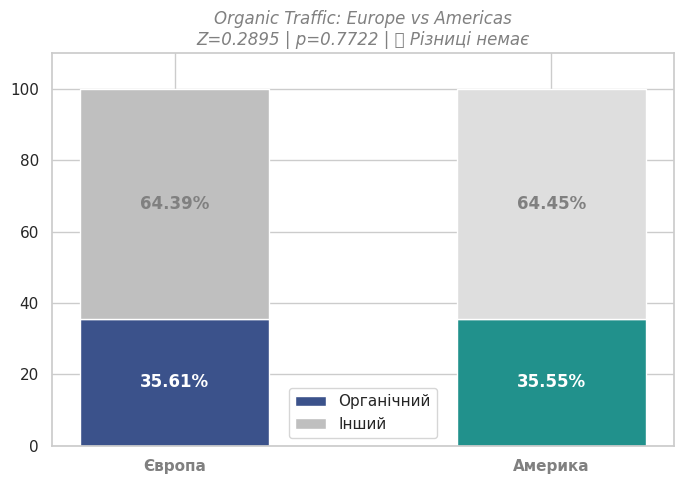

In [56]:
labels   = ['Європа', 'Америка']
organic  = np.array([europe_organic, america_organic])
total    = np.array([europe_total, america_total])
pcts     = organic / total * 100
stat, p_value = proportions_ztest(organic, total, alternative='two-sided')

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(7, 5))

ax.bar(range(2), pcts, 0.5, color=['#3B528B', '#21918C'], label='Органічний')
ax.bar(range(2), 100 - pcts, 0.5, bottom=pcts, color=['#BFBFBF', '#DEDEDE'], label='Інший')

for i, pct in enumerate(pcts):
    ax.text(i, pct / 2, f'{pct:.2f}%', ha='center', va='center', color='white', fontweight='bold')
    ax.text(i, pct + (100 - pct) / 2, f'{100 - pct:.2f}%', ha='center', va='center', color='grey', fontweight='bold')

significance = '❌ Різниці немає' if p_value > 0.05 else '✅ Різниця значуща'
ax.set_title(f'Organic Traffic: Europe vs Americas\nZ={stat:.4f} | p={p_value:.4f} | {significance}',
             fontsize=12, color='grey', fontstyle='italic')
ax.set_xticks(range(2))
ax.set_xticklabels(labels, color='grey', fontweight='bold')
ax.set_ylim(0, 110)
ax.legend()
plt.tight_layout()
plt.show()

#***📌 4. Власні інсайти***


📌 Конверсія сесій у покупки по каналах трафіку

📌 Середній чек по континентах/країнах

📌 Аналіз поведінки відписаних vs підписаних користувачів

###***✅ Конверсія сесій у покупки по каналах трафіку***

*Конверсія сесій у покупки по канал трафіку (Conversion Rate - CR) - це % сесій завершився покупкою для кожного каналу трафіку.*

🔷***Загальна кількість сесій по каналу трафіку***

In [57]:
total_sessions = df.groupby('channel')['session_id'].nunique().reset_index()
total_sessions.columns = ['channel', 'total_sessions']
total_sessions

,channel,total_sessions
0,Direct,81382
1,Organic Search,124425
2,Paid Search,94341
3,Social Search,27914
4,Undefined,21483


🔷***Загальна кількість сесій з покупкою по каналу трафіку***

In [58]:
purchase_sessions = df[df['price'].notna()].groupby('channel')['session_id'].nunique().reset_index()
purchase_sessions.columns = ['channel', 'sessions_with_purchase']
purchase_sessions

,channel,sessions_with_purchase
0,Direct,7800
1,Organic Search,11921
2,Paid Search,9042
3,Social Search,2716
4,Undefined,2059


🔷***об'єднання***

In [59]:
conversion = total_sessions.merge(purchase_sessions, on='channel', how='left')
conversion['sessions_with_purchase'] = conversion['sessions_with_purchase'].fillna(0).astype(int)
conversion

,channel,total_sessions,sessions_with_purchase
0,Direct,81382,7800
1,Organic Search,124425,11921
2,Paid Search,94341,9042
3,Social Search,27914,2716
4,Undefined,21483,2059


🔷***конверсія у %***

In [60]:
conversion['conversion_rate'] = (conversion['sessions_with_purchase'] / conversion['total_sessions'] *100).round(2)
conversion

,channel,total_sessions,sessions_with_purchase,conversion_rate
0,Direct,81382,7800,9.58
1,Organic Search,124425,11921,9.58
2,Paid Search,94341,9042,9.58
3,Social Search,27914,2716,9.73
4,Undefined,21483,2059,9.58


🔷***середня ціна по каналу трафіку***

In [61]:
average_price = df[df['price'].notna()].groupby('channel')['price'].mean().reset_index()
average_price.columns = ['channel', 'avg_price']
average_price

,channel,avg_price
0,Direct,960.887615
1,Organic Search,959.076554
2,Paid Search,941.279518
3,Social Search,932.292231
4,Undefined,971.588635


In [62]:
conversion = conversion.merge(average_price, on='channel', how='left')
conversion['avg_price'] = conversion['avg_price'].round(2)
conversion

,channel,total_sessions,sessions_with_purchase,conversion_rate,avg_price
0,Direct,81382,7800,9.58,960.89
1,Organic Search,124425,11921,9.58,959.08
2,Paid Search,94341,9042,9.58,941.28
3,Social Search,27914,2716,9.73,932.29
4,Undefined,21483,2059,9.58,971.59


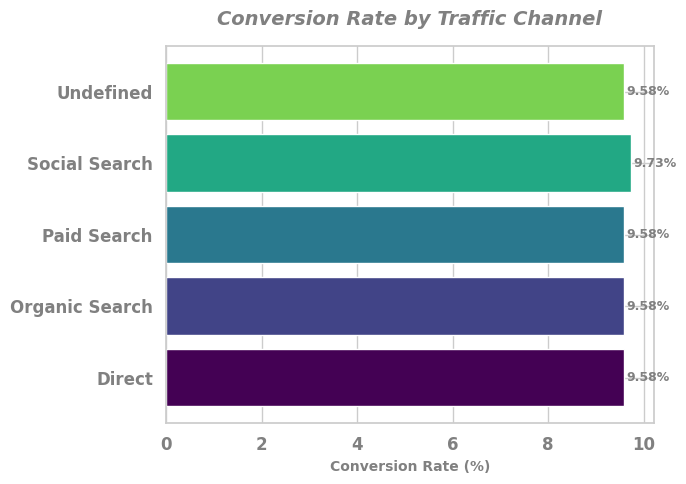

In [63]:
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.barh(conversion['channel'],
               conversion['conversion_rate'],
               color=plt.cm.viridis(np.linspace(0, 0.8, len(conversion))))

ax.set_title('Conversion Rate by Traffic Channel',
             fontsize=14, fontweight='semibold',
             color='grey', fontstyle='italic', pad=15)

ax.set_xlabel('Conversion Rate (%)', color='grey', fontweight='bold', fontsize=10)

for bar, val in zip(bars, conversion['conversion_rate']):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}%', va='center', color='grey', fontweight='bold', fontsize=9)

plt.xticks(color='grey', fontweight='bold', fontsize=12)
plt.yticks(color='grey', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

###✅***Середній чек по континентах/країнах***

🔷***Середній чек по континентах***

In [64]:
average_price_by_cont = df_purchases.groupby('continent').agg(avg_price=('price', 'mean')).reset_index().sort_values(by='avg_price', ascending=True).round(2)
display(average_price_by_cont.sort_values(by='avg_price', ascending=False).round(2))

,continent,avg_price
0,(not set),1043.20
5,Oceania,1003.38
1,Africa,977.08
3,Asia,956.14
2,Americas,952.15
4,Europe,947.87


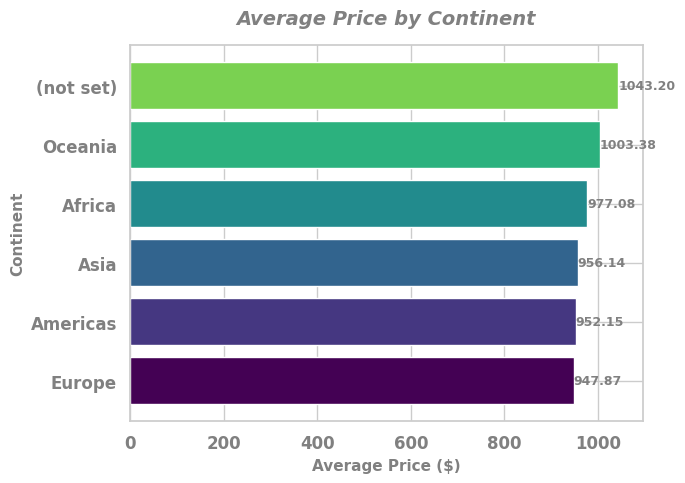

In [65]:
average_price_by_cont = (
    average_price_by_cont
    .sort_values(by='avg_price', ascending=True)
)

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.barh(average_price_by_cont['continent'],
               average_price_by_cont['avg_price'],
               color=plt.cm.viridis(np.linspace(0, 0.8, len(average_price_by_cont))))

ax.set_title('Average Price by Continent',
             fontsize=14, fontweight='semibold',
             color='grey', fontstyle='italic', pad=15)

ax.set_xlabel('Average Price ($)', fontsize=11, fontweight='bold', color='grey')

ax.set_ylabel('Continent', fontsize=11, fontweight='bold', color='grey')

for bar, val in zip(bars, average_price_by_cont['avg_price']):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', color='grey', fontweight='bold', fontsize=9)

plt.xticks(color='grey', fontweight='bold', fontsize=12)
plt.yticks(color='grey', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

🔷***Середній чек по країнах***

In [66]:
average_price_by_country = df_purchases.groupby('country').agg(avg_price=('price', 'mean')).reset_index().sort_values(by='avg_price', ascending=True).round(2)
display(average_price_by_country.sort_values(by='avg_price', ascending=False).round(2))

,country,avg_price
75,Palestine,1747.69
16,Bulgaria,1518.11
1,Albania,1401.50
106,Venezuela,1396.77
53,Kenya,1373.48
...,...,...
38,Guatemala,322.71
59,Luxembourg,293.00
22,Costa Rica,277.08
14,Bosnia & Herzegovina,187.80


🔷***топ-15 країн з найбільшим середнім чеком***

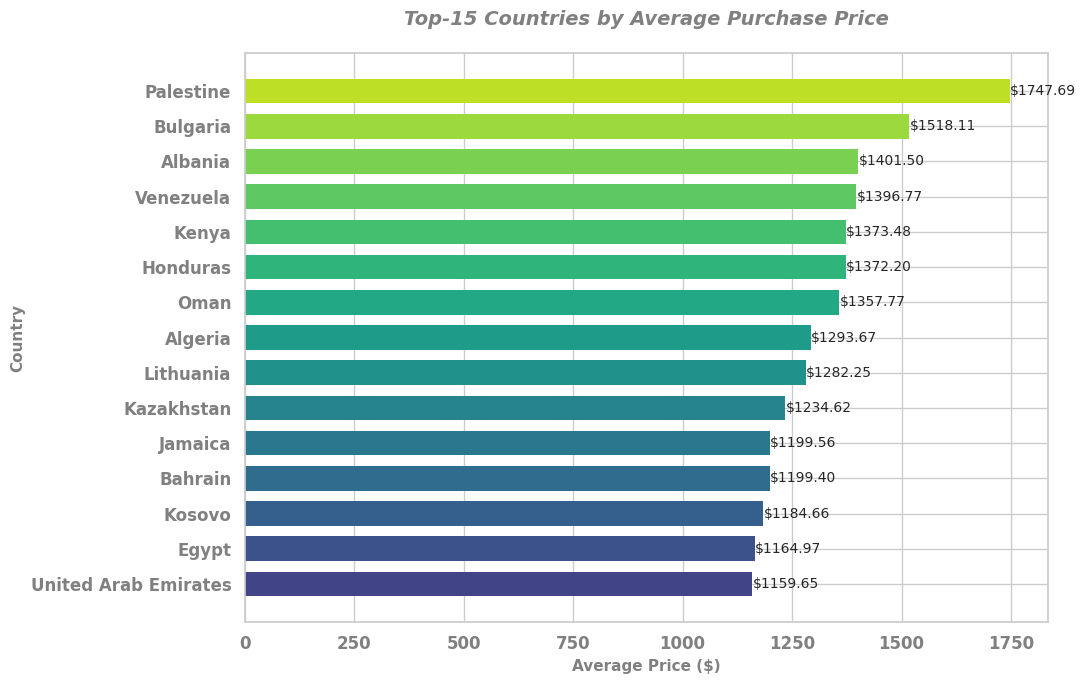

In [67]:
top_n = 15

plot_data = (average_price_by_country .sort_values(by='avg_price', ascending=False)
    .head(15).sort_values(by='avg_price', ascending=True)
)

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(11, 7))

colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(plot_data)))

bars = ax.barh(plot_data['country'], plot_data['avg_price'], color=colors, edgecolor='none', height=0.7)

ax.set_title('Top-15 Countries by Average Purchase Price',
             fontsize=14, fontweight='semibold',
             color='grey', fontstyle='italic', pad=20)

ax.set_xlabel('Average Price ($)', fontsize=11, fontweight='bold', color='grey')

ax.set_ylabel('Country', fontsize=11, fontweight='bold', color='grey')
for bar in bars:

    width = bar.get_width()

    ax.text(
        width + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'${width:.2f}',
        va='center',
        fontsize=10)

plt.xticks(color='grey', fontweight='bold', fontsize=12)
plt.yticks(color='grey', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

###❤️***Висновки: Середній чек по континентах/країнах***

* *найбільший середній чек по континентам - Oceania 1003.37 $, найменший - Europe 947.87 $. Різниця між континентами є відносно невеликою, що може свідчити про схожу купівельну поведінку користувачів у різних регіонах;*

* *найвищий середній чек серед країн зафіксовано у Palestine — 1747.69 $, далі  йдуть Bulgaria 1518.11 $ та Albania 1401.50 $. Це може свідчити про наявність преміальних або великих одиничних замовлень;*

* *невелика різниця між континентами (~55 $) свідчить про глобально рівномірне ціноутворення, тоді як велиуий розкид між країнами Palestine vs Інші, вказує на наявність окремих ринків з преміальними замовленнями чи малою вибіркою даних.*

###✅ ***Аналіз поведінки відписаних vs підписаних користувачів***

In [68]:
df_register = df[df['account_id'] !=0].copy()
df_register

,date,session_id,continent,country,device,browser,mobile_model_name,operating_system,language,traffic_source,channel,account_id,is_verified,is_unsubscribed,category,product_name,price,description
28,2020-11-01,258365862,Americas,United States,desktop,Chrome,ChromeBook,<Other>,Unknown,organic,Organic Search,649280,True,True,Bar furniture,FRANKLIN,149.0,"Bar stool with backrest, foldable, 74 cm"
50,2020-11-01,1390241795,Americas,United States,desktop,Chrome,Safari,Web,en-us,(none),Direct,676055,True,True,No Purchase,No Purchase,NaN,No Purchase
58,2020-11-01,7169173190,Americas,United States,desktop,Chrome,Safari,Web,en-us,organic,Organic Search,677981,False,False,No Purchase,No Purchase,NaN,No Purchase
80,2020-11-01,2773474671,Asia,Philippines,desktop,Chrome,ChromeBook,Web,Unknown,organic,Paid Search,672927,True,False,No Purchase,No Purchase,NaN,No Purchase
96,2020-11-01,1585785791,Americas,Canada,desktop,Chrome,ChromeBook,<Other>,en-us,organic,Organic Search,653089,True,False,No Purchase,No Purchase,NaN,No Purchase
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
334542,2021-01-27,6382695594,Americas,United States,desktop,Chrome,Chrome,Web,en,(none),Direct,652887,False,False,No Purchase,No Purchase,NaN,No Purchase
334550,2021-01-27,2019826196,Asia,Japan,mobile,Chrome,Pixel 4 XL,Android,Unknown,organic,Organic Search,675528,True,False,No Purchase,No Purchase,NaN,No Purchase
334560,2021-01-27,1765771894,Americas,United States,desktop,Chrome,Chrome,Windows,Unknown,(none),Direct,660454,True,False,No Purchase,No Purchase,NaN,No Purchase
334562,2021-01-27,7859393828,Americas,Canada,desktop,Chrome,Chrome,Windows,en-ca,(none),Direct,647640,True,False,No Purchase,No Purchase,NaN,No Purchase


In [69]:
subscribed = df_register[df_register['is_unsubscribed'] == False]
unsubscribed = df_register[df_register['is_unsubscribed'] == True]

In [70]:
def group_stats(group, name):
    purchases = group[group['price'].notna()]

    return {
        'Group': name,
        'Total_Sessions': group['session_id'].nunique(),
        'Purchase_Sessions': purchases['session_id'].nunique(),
        'Conversion_Rate': round(purchases['session_id'].nunique() / group['session_id'].nunique() * 100, 2),
        'Avg_Order ($)': round(purchases['price'].mean(), 2),
        'Total_Sales ($)': round(purchases['price'].sum(), 2),
        'Median_Order ($)': round(purchases['price'].median(), 2),
    }

stats = pd.DataFrame([
    group_stats(subscribed,   'Subscribed'),
    group_stats(unsubscribed, 'Unsubscribed')
])

display(stats)

,Group,Total_Sessions,Purchase_Sessions,Conversion_Rate,Avg_Order ($),Total_Sales ($),Median_Order ($)
0,Subscribed,23210,2334,10.06,921.51,2150796.9,395.0
1,Unsubscribed,4735,447,9.44,965.82,431721.6,450.0


###❤️***Висновки: Аналіз поведінки Відписаних vs Підписаних користувачів***

***Загальна кількість сесій:***

  Підписані:   23.210 | Відписані: 4.735

  -> Підписаних користувачів у ~5 разів більше

***Конверсія (сесії → покупка):***

  Підписані:   10.06% | Відписані: 9.44%

  -> різниця мінімальна - відписка від розсилки практично не впливає на конверсію

***Середній чек:***

  Підписані:   921.51 $ | Відписані: 965.82 $

  -> Відписані витрачають на ~$44 більше за одне замовлення, проте різниця статистично незначуща (Mann-Whitney p-value = 0.6208 > 0.05)

***Медіана чеку:***

  Підписані:   395.00 $  | Відписані: 450.00 $

  -> Медіана відписаних вища - половина їх замовлень перевищує 450 $ з 395 $ у підписаних

***Загальні продажі:***

  Підписані:   2150.796 $ | Відписані: 4317.21 $

  -> Підписані генерують у ~5 разів більше виручки,  що пропорційно їх кількості

#***📌Tableau***

[DashBoard ](https://public.tableau.com/views/Portfolio_1_DASHBOARD_2/Dashboard1?:language=en-US&publish=yes&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link)

[DashBoard](https:/public.tableau.com/views/Portfolio_1_DASHBOARD_1/Dashboard2?:language=en-US&publish=yes&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link)


